In [2]:
import numpy as np
import matplotlib.pyplot as plt
import random
import math
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
import umap

SEED = 42
np.random.seed(SEED)
random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)


/home/anushkasingh/Desktop/Thesis/Code/thesis/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: cpu


In [3]:
def gaussian(x, mu, sigma, A=1.0):
    return A * np.exp(-0.5 * ((x - mu) / sigma)**2)

def make_template(x, peaks):
    """peaks: list of (mu, sigma, amplitude)"""
    y = np.zeros_like(x)
    for mu, sigma, A in peaks:
        y += gaussian(x, mu, sigma, A)
    return y

def plot_spectra(x, ys, labels=None, title="Spectra", n=6):
    plt.figure(figsize=(10,4))
    for i, y in enumerate(ys[:n]):
        lab = labels[i] if labels is not None else f"{i}"
        plt.plot(x, y, label=lab, alpha=0.8)
    plt.gca().invert_xaxis()
    plt.xlabel("Wavenumber (cm^-1)")
    plt.ylabel("Intensity (a.u.)")
    plt.title(title)
    if labels is not None: plt.legend()
    plt.show()


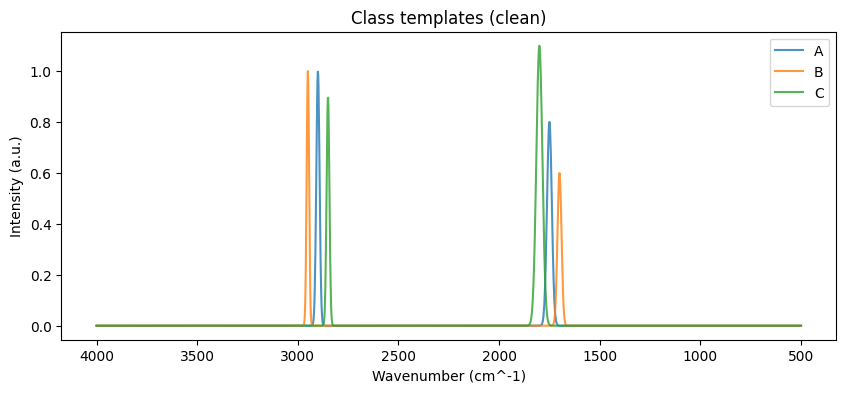

In [4]:
# wavenumber axis typical IR fingerprint: 4000 -> 500 cm^-1, but we'll use 4000->500
x = np.linspace(4000, 500, 2048)  # descending axis; we'll keep increasing for arrays but plot inverted

# Define 3 "chemical" classes by peak positions and widths
templates = []
templates.append(make_template(x, peaks=[(2900, 8, 1.0), (1750, 12, 0.8)]))  # class A
templates.append(make_template(x, peaks=[(2950, 6, 1.0), (1700, 10, 0.6)]))  # class B
templates.append(make_template(x, peaks=[(2850, 7, 0.9), (1800, 15, 1.1)]))  # class C

plot_spectra(x, templates, labels=["A","B","C"], title="Class templates (clean)")


In [5]:
class BaselineGenerator:
    """
    Sample smooth additive baselines and multiplicative vapor-pressure-like scaling.
    Components:
      - low-order polynomial (order up to 3)
      - optional sinusoidal fringe
      - multiplicative scaling (vapor pressure)
      - small gaussian bumps (to emulate weak water bands if desired)
    """
    def __init__(self, x, poly_scale=(0.0, 0.002), poly_order=3,
                 fringe_prob=0.4, fringe_amp=(0.0, 0.004), fringe_freq=(0.0005, 0.003),
                 vp_scale=(0.9, 1.1), noise_std=(0.0, 0.003), device="cpu"):
        self.x = x
        self.N = len(x)
        self.poly_scale = poly_scale
        self.poly_order = poly_order
        self.fringe_prob = fringe_prob
        self.fringe_amp = fringe_amp
        self.fringe_freq = fringe_freq
        self.vp_scale = vp_scale
        self.noise_std = noise_std
        self.device = device

        # normalize x to [-1,1] for stable polynomials
        self.xn = (x - x.mean()) / (x.std() + 1e-12)

    def sample_polynomial(self, B):
        # sample coefficients for Legendre-like polynomial basis
        # we'll use powers of xn for simplicity
        coeffs = np.random.uniform(self.poly_scale[0], self.poly_scale[1], size=(B, self.poly_order+1))
        # decrease higher-order coeff magnitude
        for k in range(coeffs.shape[1]):
            coeffs[:,k] *= (0.5**k)
        out = np.zeros((B, self.N), dtype=float)
        for k in range(coeffs.shape[1]):
            out += np.outer(coeffs[:,k], self.xn**k)
        return out

    def sample_fringe(self, B):
        amps = np.random.uniform(self.fringe_amp[0], self.fringe_amp[1], size=(B,1))
        freqs = np.random.uniform(self.fringe_freq[0], self.fringe_freq[1], size=(B,1))
        phases = np.random.uniform(0, 2*np.pi, size=(B,1))
        xv = self.x[None,:]
        return (amps * np.sin(2*np.pi * freqs * xv + phases))

    def sample(self, batch_y):
        """
        batch_y: shape (B, N) the original spectra, used to apply multiplicative scaling
        returns: y_aug (B,N), baseline (B,N), scale (B,)
        """
        B = batch_y.shape[0]
        baseline = self.sample_polynomial(B)
        if np.random.rand() < self.fringe_prob:
            baseline += self.sample_fringe(B)
        scale = np.random.uniform(self.vp_scale[0], self.vp_scale[1], size=(B,1))
        y = batch_y * scale + baseline
        noise = np.random.normal(0, np.random.uniform(self.noise_std[0], self.noise_std[1], size=(B,1)), size=(B,self.N))
        y = y + noise
        return y.astype(np.float32), baseline.astype(np.float32), scale.astype(np.float32)


Dataset shape: (600, 2048)


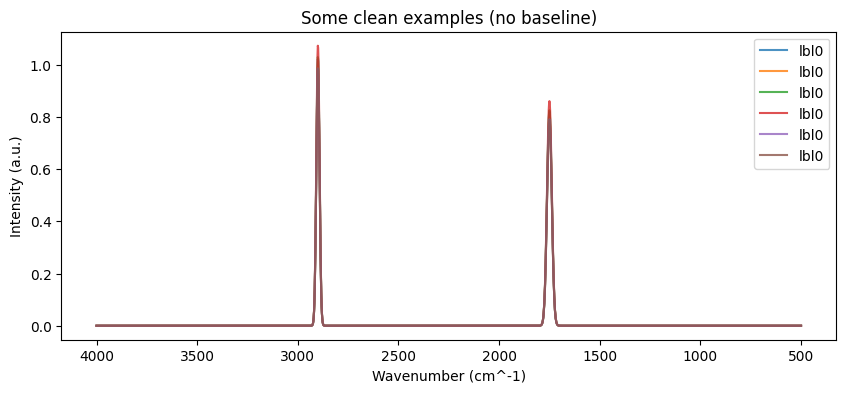

In [6]:
# create dataset: N_per_class samples each with small amplitude jitter
N_per_class = 200
all_y = []
all_labels = []
for ci, tmpl in enumerate(templates):
    for i in range(N_per_class):
        # small amplitude jitter and local small peak shifts
        amp_scale = np.random.normal(1.0, 0.05)
        y = tmpl * amp_scale
        # small broad baseline already (keep small)
        y = y.astype(np.float32)
        all_y.append(y)
        all_labels.append(ci)

all_y = np.stack(all_y, axis=0)  # (M, N)
all_labels = np.array(all_labels)
print("Dataset shape:", all_y.shape)

# visualize a few clean spectra
plot_spectra(x, all_y, labels=[f"lbl{l}" for l in all_labels[:6]], title="Some clean examples (no baseline)")


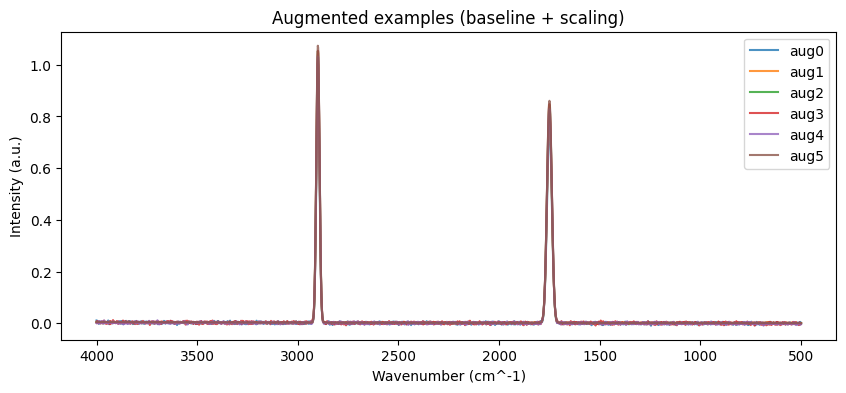

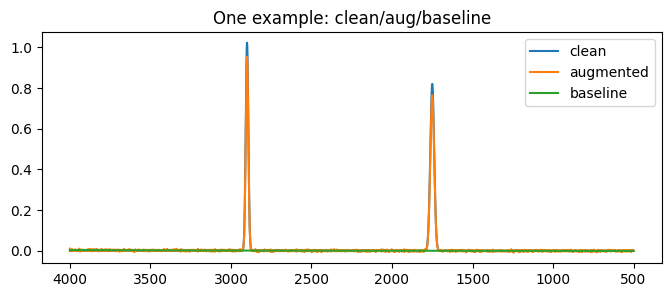

In [7]:
aug = BaselineGenerator(x, device=device)
sample_batch = all_y[:6]
y_aug, baseline, scale = aug.sample(sample_batch)
plot_spectra(x, y_aug, labels=[f"aug{i}" for i in range(6)], title="Augmented examples (baseline + scaling)")
# also plot baseline overlays for first example
plt.figure(figsize=(8,3))
plt.plot(x, sample_batch[0], label="clean")
plt.plot(x, y_aug[0], label="augmented")
plt.plot(x, baseline[0], label="baseline")
plt.gca().invert_xaxis(); plt.legend(); plt.title("One example: clean/aug/baseline")
plt.show()


In [8]:
class SpecEncoder(nn.Module):
    def __init__(self, out_dim=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv1d(1, 32, kernel_size=11, padding=5), nn.ReLU(), nn.MaxPool1d(2),
            nn.Conv1d(32, 64, kernel_size=11, padding=5), nn.ReLU(), nn.MaxPool1d(2),
            nn.Conv1d(64, 128, kernel_size=9, padding=4), nn.ReLU(), nn.AdaptiveAvgPool1d(1)
        )
        self.fc = nn.Linear(128, out_dim)
        self.proj = nn.Sequential(nn.Linear(out_dim, out_dim), nn.ReLU(), nn.Linear(out_dim, out_dim))

    def forward(self, x):
        # x: (B, N)
        z = self.net(x.unsqueeze(1)).squeeze(-1)  # (B, 128)
        z = self.fc(z)                            # (B, out_dim)
        p = self.proj(z)
        return z, p


In [9]:
def nt_xent(p_i, p_j, temperature=0.2):
    """
    p_i, p_j: tensors (B, D)
    returns scalar loss
    """
    B = p_i.shape[0]
    z = torch.cat([F.normalize(p_i, dim=1), F.normalize(p_j, dim=1)], dim=0)  # (2B, D)
    sim = torch.matmul(z, z.T)  # (2B, 2B) cosine similarities
    # mask out self similarities
    mask = (~torch.eye(2*B, dtype=torch.bool, device=sim.device)).float()
    sim = sim / temperature
    exp_sim = torch.exp(sim) * mask
    # for each i, positive index:
    positives = torch.cat([torch.arange(B, 2*B), torch.arange(0, B)]).to(sim.device)
    numerator = torch.exp((torch.sum(F.normalize(p_i, dim=1) * F.normalize(p_j, dim=1), dim=1) / temperature))
    # compute denominator: sum over row i of exp_sim
    denom = exp_sim.sum(dim=1)
    # construct positive terms aligned with denom order
    # Build positive_exp vector aligned to row order [p_i..p_j] concatenation
    pos_exp = torch.cat([torch.exp((F.normalize(p_i, dim=1) * F.normalize(p_j, dim=1)).sum(dim=1)/temperature),
                         torch.exp((F.normalize(p_j, dim=1) * F.normalize(p_i, dim=1)).sum(dim=1)/temperature)])
    loss = -torch.log(pos_exp / denom).mean()
    return loss


In [10]:
def train_contrastive(encoder, X, augmentor, epochs=20, batch_size=128, lr=1e-3, device='cpu'):
    encoder.to(device)
    optimizer = torch.optim.Adam(encoder.parameters(), lr=lr)
    dataset = TensorDataset(torch.tensor(X, dtype=torch.float32))
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=True, drop_last=True)
    encoder.train()
    for ep in range(epochs):
        total_loss = 0.0
        for batch_idx, (xb,) in enumerate(loader):
            xb = xb.to(device)           # xb: (B,N) clean spectra
            x1, _, _ = augmentor.sample(xb.cpu().numpy())
            x2, _, _ = augmentor.sample(xb.cpu().numpy())
            x1 = torch.tensor(x1, dtype=torch.float32).to(device)
            x2 = torch.tensor(x2, dtype=torch.float32).to(device)
            _, p1 = encoder(x1)
            _, p2 = encoder(x2)
            loss = nt_xent(p1, p2, temperature=0.2)
            optimizer.zero_grad(); loss.backward(); optimizer.step()
            total_loss += loss.item()
        print(f"Epoch {ep+1}/{epochs}, loss={total_loss/len(loader):.4f}")
    return encoder

# instantiate and train (small model)
enc = SpecEncoder(out_dim=64)
aug = BaselineGenerator(x)
enc = train_contrastive(enc, all_y, aug, epochs=20, batch_size=128, lr=1e-3, device=device)


Epoch 1/20, loss=5.5412
Epoch 2/20, loss=5.5400
Epoch 3/20, loss=5.5269
Epoch 4/20, loss=5.4279
Epoch 5/20, loss=5.2061
Epoch 6/20, loss=4.8849
Epoch 7/20, loss=4.7369
Epoch 8/20, loss=4.7518
Epoch 9/20, loss=4.7220
Epoch 10/20, loss=4.7199
Epoch 11/20, loss=4.7036
Epoch 12/20, loss=4.6653
Epoch 13/20, loss=4.6701
Epoch 14/20, loss=4.6367
Epoch 15/20, loss=4.6173
Epoch 16/20, loss=4.5980
Epoch 17/20, loss=4.5904
Epoch 18/20, loss=4.5484
Epoch 19/20, loss=4.5185
Epoch 20/20, loss=4.5150


pos mean dist: 0.024253882 neg mean dist: 0.26168317


/tmp/ipykernel_21284/3681326061.py:23: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([pos_d, neg_d], labels=["pos", "neg"]); plt.title("Invariance distances (lower pos is better)"); plt.show()


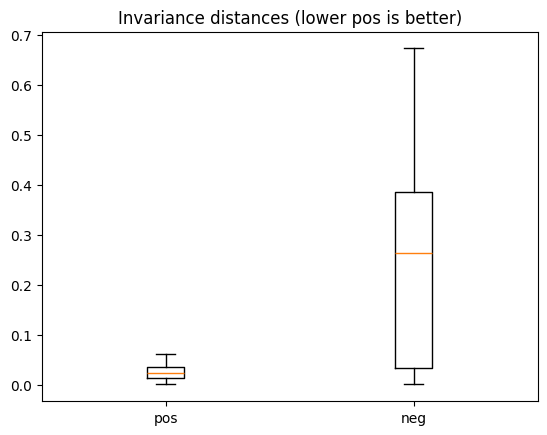

In [11]:
@torch.no_grad()
def compute_invariance(encoder, X, augmentor, device='cpu', n_samples=200):
    encoder.eval()
    M = X.shape[0]
    idx = np.random.choice(M, size=min(n_samples, M), replace=False)
    x_sel = X[idx]
    x_aug, _, _ = augmentor.sample(x_sel)
    z_orig, _ = encoder(torch.tensor(x_sel, dtype=torch.float32).to(device))
    z_aug, _ = encoder(torch.tensor(x_aug, dtype=torch.float32).to(device))
    z_orig = F.normalize(z_orig, dim=1)
    z_aug  = F.normalize(z_aug, dim=1)
    pos_dists = torch.norm(z_orig - z_aug, dim=1).cpu().numpy()
    # negative distances: match x_sel[i] with random other j
    rand_idx = np.random.choice(M, size=len(idx), replace=True)
    x_rand = X[rand_idx]
    z_rand, _ = encoder(torch.tensor(x_rand, dtype=torch.float32).to(device))
    z_rand = F.normalize(z_rand, dim=1)
    neg_dists = torch.norm(z_orig - z_rand, dim=1).cpu().numpy()
    return pos_dists, neg_dists

pos_d, neg_d = compute_invariance(enc, all_y, aug, device=device, n_samples=300)
print("pos mean dist:", pos_d.mean(), "neg mean dist:", neg_d.mean())
plt.boxplot([pos_d, neg_d], labels=["pos", "neg"]); plt.title("Invariance distances (lower pos is better)"); plt.show()


/home/anushkasingh/Desktop/Thesis/Code/thesis/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


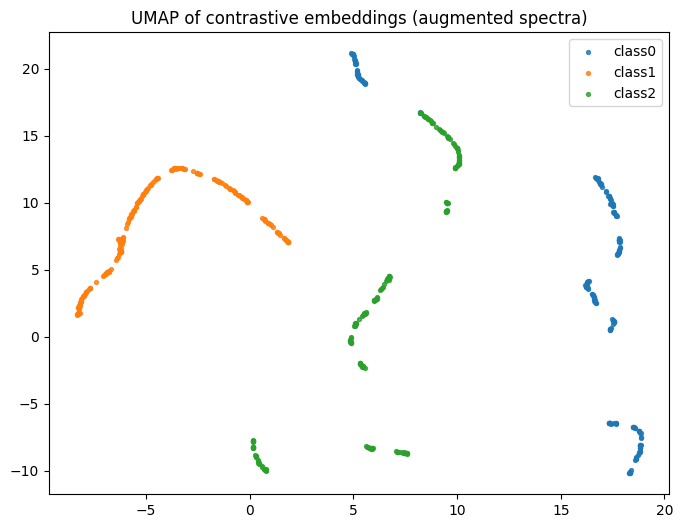

In [12]:
@torch.no_grad()
def get_embeddings(encoder, X, augmentor=None, device='cpu', apply_aug=False):
    encoder.eval()
    xs = X.copy()
    if apply_aug:
        xs,_,_ = augmentor.sample(xs)
    with torch.no_grad():
        zs, _ = encoder(torch.tensor(xs, dtype=torch.float32).to(device))
    return zs.cpu().numpy()

# Get embeddings for *augmented* spectra to test robustness
Z = get_embeddings(enc, all_y, augmentor=aug, device=device, apply_aug=True)
reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, metric='cosine', random_state=SEED)
Z2 = reducer.fit_transform(Z)

plt.figure(figsize=(8,6))
for c in np.unique(all_labels):
    mask = (all_labels == c)
    plt.scatter(Z2[mask,0], Z2[mask,1], label=f"class{c}", s=8, alpha=0.8)
plt.legend(); plt.title("UMAP of contrastive embeddings (augmented spectra)"); plt.show()
